In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!unzip "/content/drive/MyDrive/audio_filtered-20250604T101444Z-1-001.zip"
!unzip "/content/drive/MyDrive/video-20250604T101425Z-1-001.zip"


Mounted at /content/drive
Archive:  /content/drive/MyDrive/audio_filtered-20250604T101444Z-1-001.zip
  inflating: audio_filtered/656_BoAW_openSMILE_2.3.0_MFCC.csv  
  inflating: audio_filtered/708_BoAW_openSMILE_2.3.0_MFCC.csv  
  inflating: audio_filtered/664_BoAW_openSMILE_2.3.0_MFCC.csv  
  inflating: audio_filtered/693_BoAW_openSMILE_2.3.0_MFCC.csv  
  inflating: audio_filtered/661_BoAW_openSMILE_2.3.0_MFCC.csv  
  inflating: audio_filtered/659_BoAW_openSMILE_2.3.0_MFCC.csv  
  inflating: audio_filtered/709_BoAW_openSMILE_2.3.0_MFCC.csv  
  inflating: audio_filtered/669_BoAW_openSMILE_2.3.0_MFCC.csv  
  inflating: audio_filtered/710_BoAW_openSMILE_2.3.0_MFCC.csv  
  inflating: audio_filtered/718_BoAW_openSMILE_2.3.0_MFCC.csv  
  inflating: audio_filtered/682_BoAW_openSMILE_2.3.0_MFCC.csv  
  inflating: audio_filtered/699_BoAW_openSMILE_2.3.0_MFCC.csv  
  inflating: audio_filtered/679_BoAW_openSMILE_2.3.0_MFCC.csv  
  inflating: audio_filtered/652_BoAW_openSMILE_2.3.0_MFCC.csv  
  i

#Audio

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
import glob
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import matplotlib.pyplot as plt
import os

# Check GPU
if tf.config.list_physical_devices('GPU'):
    print("TensorFlow is using GPU")
    for gpu in tf.config.list_physical_devices('GPU'):
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("TensorFlow is using CPU")

# Load and preprocess with train/test split
def load_and_preprocess_audio_data(csv_folder_path, labels_list, test_size=0.2, random_state=42):
    filepaths = sorted(glob.glob(csv_folder_path + '/*.csv'))
    assert len(labels_list) == len(filepaths), "Labels count must match number of CSV files."

    data_sequences, processed_labels, filenames_out, file_ids_out = [], [], [], []
    expected_cols = None

    # First pass: determine expected number of columns
    for filepath in filepaths:
        try:
            df = pd.read_csv(filepath).apply(pd.to_numeric, errors='coerce').fillna(0)
            if not df.empty and df.shape[1] > 0:
                expected_cols = df.shape[1]
                break
        except:
            continue

    if expected_cols is None:
        raise ValueError("No valid CSV files found")

    print(f"Expected feature columns: {expected_cols}")

    # Second pass: process all files with consistent dimensions
    for idx, filepath in enumerate(filepaths):
        try:
            df = pd.read_csv(filepath).apply(pd.to_numeric, errors='coerce').fillna(0)
            if df.empty or df.shape[1] == 0:
                print(f"Skipping empty file: {filepath}")
                continue

            # Handle dimension mismatch
            if df.shape[1] != expected_cols:
                print(f"Warning: {filepath} has {df.shape[1]} columns, expected {expected_cols}. Skipping.")
                continue

            # Extract file ID from filename
            file_id = os.path.basename(filepath).split('_')[0]

            # Aggregate features: mean, std, min, max for each column
            features_mean = df.mean().values
            features_std = df.std().values
            features_min = df.min().values
            features_max = df.max().values

            # Concatenate all statistics
            aggregated_features = np.concatenate([features_mean, features_std, features_min, features_max])

            data_sequences.append(aggregated_features)
            processed_labels.append(labels_list[idx])
            filenames_out.append(filepath)
            file_ids_out.append(file_id)
        except Exception as e:
            print(f"Error processing {filepath}: {e}")
            continue

    X = np.array(data_sequences)
    y = np.array(processed_labels)
    file_ids = np.array(file_ids_out)

    print(f"Successfully loaded: {len(data_sequences)}/{len(filepaths)} files")
    print(f"Feature dimension after aggregation: {X.shape[1]}")

    # Train/Test Split - include file IDs to track which samples are in test set
    X_train, X_test, y_train, y_test, fname_train, fname_test, ids_train, ids_test = train_test_split(
        X, y, filenames_out, file_ids, test_size=test_size, random_state=random_state
    )

    # Fit scaler only on training data
    scaler = StandardScaler().fit(X_train)

    # Scale both train and test
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, y_train, X_test_scaled, y_test, scaler, fname_train, fname_test, ids_train, ids_test


def calculate_metrics(y_true, y_pred):
    """Calculate comprehensive metrics"""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

def plot_predictions(y_true, y_pred, title="Predictions vs Actual"):
    """Plot predictions vs actual values"""
    plt.figure(figsize=(10, 6))
    plt.scatter(y_true, y_pred, alpha=0.6, s=100, edgecolors='k')
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--', lw=2)
    plt.xlabel('Actual PHQ-8 Score', fontsize=12)
    plt.ylabel('Predicted PHQ-8 Score', fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Training function with multiple model types
def train_audio_model():
    csv_folder_path = '/content/audio_filtered'
    labels_list = [2, 3, 4, 0, 6, 7, 0, 4, 22, 15, 4, 21, 2, 7, 1, 2, 6, 8, 3, 13, 11, 20, 5, 1, 5, 10, 2, 4, 4, 1, 12, 8, 18, 5, 5, 12, 7, 10, 15, 11, 1, 7, 9, 11, 15, 23, 16, 20, 5, 11, 14, 10, 11, 18, 10, 10, 7, 7, 13, 4, 0, 20, 0, 0, 12, 0, 19, 7, 0, 0, 9, 13, 9, 2, 5, 12, 16, 1, 2, 10, 16, 0, 7, 15, 8, 11, 2, 17, 14, 9, 9, 1, 2, 7, 5, 5, 7, 7, 9, 11, 0, 0, 17, 2, 3, 0, 10, 12, 0, 12, 10, 16, 3, 3, 7, 10, 3, 3, 10, 12, 0, 3, 6, 20, 5, 0, 1, 3, 2, 1, 10, 2, 8, 0, 0, 2, 1, 19, 18, 6, 1, 7, 1, 0, 1, 18, 2, 9, 4, 1, 17, 1, 1, 6, 3, 5, 16, 17, 9, 0, 0, 2, 9, 0, 4, 3, 3, 0, 3, 0, 4, 6, 3, 2, 1, 7, 1, 7, 1, 15, 9, 2, 4, 0, 0, 3, 2, 8, 0, 5, 0, 13, 4, 12, 2, 5, 7, 2, 0, 1, 3, 12, 4, 6, 0, 0, 9, 22, 2, 0, 3, 0, 0, 0, 1, 10, 2, 9, 15, 16, 19, 17, 17, 19, 3, 5, 7, 4, 6, 12, 8, 0, 11, 16, 2, 19, 2, 9, 2, 5, 3, 7, 0, 13, 0, 12, 8, 22, 12, 6, 18, 7, 19, 13, 11, 0, 3, 7, 13, 5, 19, 16, 0, 8, 20, 1, 0, 10, 7, 0, 0, 7, 15, 1, 3]

    print(f"Total samples: {len(labels_list)}")

    # Load and split data
    X_train, y_train, X_test, y_test, scaler, fname_train, fname_test, ids_train, ids_test = load_and_preprocess_audio_data(
        csv_folder_path, labels_list
    )

    print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")
    print(f"Feature dimension: {X_train.shape[1]}")
    print(f"File IDs in train set: {len(ids_train)}, in test set: {len(ids_test)}")

    # Train multiple models
    print("\n" + "="*60)
    print("TRAINING AUDIO MODELS")
    print("="*60)

    models = {}
    results = {}

    # 1. Random Forest
    print("\n[1/3] Training Random Forest...")
    rf_model = RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    )
    rf_model.fit(X_train, y_train)
    models['Random Forest'] = rf_model

    # 2. Gradient Boosting
    print("[2/3] Training Gradient Boosting...")
    gb_model = GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        min_samples_split=5,
        min_samples_leaf=2,
        subsample=0.8,
        random_state=42
    )
    gb_model.fit(X_train, y_train)
    models['Gradient Boosting'] = gb_model

    # 3. Simple Neural Network (smaller, regularized)
    print("[3/3] Training Neural Network...")
    nn_model = keras.Sequential([
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)),
        layers.Dropout(0.4),
        layers.Dense(32, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)),
        layers.Dropout(0.3),
        layers.Dense(16, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)),
        layers.Dropout(0.2),
        layers.Dense(1)
    ])

    nn_model.compile(
        optimizer=keras.optimizers.Adam(0.001),
        loss='mse',
        metrics=[keras.metrics.MeanAbsoluteError(), keras.metrics.RootMeanSquaredError()]
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True, verbose=0
    )

    nn_model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=20,
        batch_size=16,
        callbacks=[early_stop],
        verbose=0
    )
    models['Neural Network'] = nn_model

    # Evaluate all models
    print("\n" + "="*60)
    print("AUDIO MODEL COMPARISON")
    print("="*60)

    for name, model in models.items():
        if name == 'Neural Network':
            y_pred_train = model.predict(X_train, verbose=0).flatten()
            y_pred_test = model.predict(X_test, verbose=0).flatten()
        else:
            y_pred_train = model.predict(X_train)
            y_pred_test = model.predict(X_test)

        train_metrics = calculate_metrics(y_train, y_pred_train)
        test_metrics = calculate_metrics(y_test, y_pred_test)

        results[name] = {
            'train': train_metrics,
            'test': test_metrics,
            'y_pred_test': y_pred_test,
            'y_test': y_test
        }

        print(f"\n{name}:")
        print(f"  Train MAE: {train_metrics['MAE']:.4f} | Test MAE: {test_metrics['MAE']:.4f}")
        print(f"  Train R²: {train_metrics['R2']:.4f} | Test R²: {test_metrics['R2']:.4f}")

    # Select best model: prioritize positive R², then lowest MAE
    models_with_positive_r2 = {name: res for name, res in results.items() if res['test']['R2'] > 0}

    if models_with_positive_r2:
        # Choose model with best (lowest) MAE among those with positive R²
        best_model_name = min(models_with_positive_r2.keys(),
                             key=lambda x: models_with_positive_r2[x]['test']['MAE'])
        print(f"\n Selected from {len(models_with_positive_r2)} models with positive R²")
    else:
        # Fallback: if all R² are negative, choose the one closest to 0 (least bad)
        best_model_name = max(results.keys(), key=lambda x: results[x]['test']['R2'])
        print(f"\n  WARNING: All models have negative R² (worse than mean prediction)")
        print(f"   Selecting model with R² closest to 0 (least bad)")

    best_model = models[best_model_name]
    best_metrics = results[best_model_name]['test']

    print(f"\n{'='*60}")
    print(f" Best Audio Model: {best_model_name}")
    print(f"{'='*60}")
    for metric, value in best_metrics.items():
        print(f"{metric}: {value:.4f}")

    # Plot best model
    plot_predictions(
        results[best_model_name]['y_test'],
        results[best_model_name]['y_pred_test'],
        f"Audio Model ({best_model_name}): Test Set Predictions"
    )

    return best_model, scaler, best_model_name, best_metrics, X_train.shape[1], ids_train, ids_test

TensorFlow is using GPU


TensorFlow version: 2.19.0
Total samples: 275
Expected feature columns: 102
Successfully loaded: 219/275 files
Feature dimension after aggregation: 408
Train samples: 175, Test samples: 44
Feature dimension: 408
File IDs in train set: 175, in test set: 44

TRAINING AUDIO MODELS

[1/3] Training Random Forest...
[2/3] Training Gradient Boosting...
[3/3] Training Neural Network...

AUDIO MODEL COMPARISON

Random Forest:
  Train MAE: 2.1960 | Test MAE: 4.8178
  Train R²: 0.7906 | Test R²: -0.0154

Gradient Boosting:
  Train MAE: 0.0358 | Test MAE: 4.8562
  Train R²: 0.9999 | Test R²: 0.0229

Neural Network:
  Train MAE: 2.9001 | Test MAE: 5.1281
  Train R²: 0.6014 | Test R²: -0.2405

 Selected from 1 models with positive R²

 Best Audio Model: Gradient Boosting
MAE: 4.8562
MSE: 39.2131
RMSE: 6.2620
R2: 0.0229


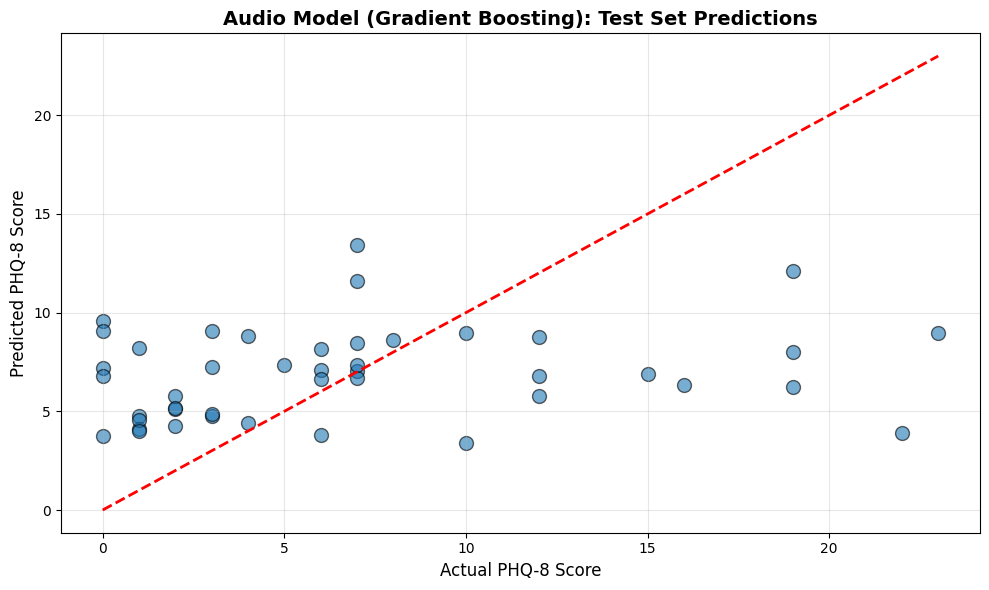

In [ ]:
print("TensorFlow version:", tf.__version__)
audio_model, audio_scaler, audio_model_name, audio_test_metrics, audio_feature_dim, ids_train, ids_test = train_audio_model()

#Video

In [ ]:
import pandas as pd
import tensorflow as tf
import os
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

N_FEATURES = 49
CONFIDENCE_THRESHOLD = 0.8

def load_and_aggregate_video_features(file_paths, confidence_threshold=0.8):
    """Load video data and aggregate features (mean, std, min, max)"""
    feature_column_names = [
        'pose_Tx', 'pose_Ty', 'pose_Tz', 'pose_Rx', 'pose_Ry', 'pose_Rz',
        'gaze_0_x', 'gaze_0_y', 'gaze_0_z', 'gaze_1_x', 'gaze_1_y', 'gaze_1_z', 'gaze_angle_x', 'gaze_angle_y',
        'AU01_r', 'AU02_r', 'AU04_r', 'AU05_r', 'AU06_r', 'AU07_r', 'AU09_r', 'AU10_r', 'AU12_r', 'AU14_r', 'AU15_r',
        'AU17_r', 'AU20_r', 'AU23_r', 'AU25_r', 'AU26_r', 'AU45_r',
        'AU01_c', 'AU02_c', 'AU04_c', 'AU05_c', 'AU06_c', 'AU07_c', 'AU09_c', 'AU10_c', 'AU12_c', 'AU14_c', 'AU15_c',
        'AU17_c', 'AU20_c', 'AU23_c', 'AU25_c', 'AU26_c', 'AU28_c', 'AU45_c'
    ]

    aggregated_features = []
    file_ids = []

    for file_path in file_paths:
        # Extract file ID from filename
        file_id = os.path.basename(file_path).split('_')[0]
        try:
            df = pd.read_csv(file_path)

            if 'confidence' in df.columns:
                df_filtered = df[df['confidence'] >= confidence_threshold].copy()
            else:
                df_filtered = df.copy()

            if df_filtered.empty:
                # Use zeros if no data
                features = np.zeros(len(feature_column_names) * 4)
            else:
                available_cols = [col for col in feature_column_names if col in df_filtered.columns]
                df_features = df_filtered[available_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

                # Aggregate: mean, std, min, max
                features_mean = df_features.mean().values
                features_std = df_features.std().values
                features_min = df_features.min().values
                features_max = df_features.max().values

                features = np.concatenate([features_mean, features_std, features_min, features_max])

            aggregated_features.append(features)
            file_ids.append(file_id)
        except Exception as e:
            print(f"Error processing {file_path}: {e}")
            features = np.zeros(len(feature_column_names) * 4)
            aggregated_features.append(features)
            file_ids.append(file_id)

    return np.array(aggregated_features), np.array(file_ids)


def calculate_video_metrics(y_true, y_pred):
    """Calculate comprehensive metrics"""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}


def plot_video_predictions(y_true, y_pred, title="Video Model: Predictions vs Actual"):
    """Plot predictions vs actual values"""
    plt.figure(figsize=(10, 6))
    plt.scatter(y_true, y_pred, alpha=0.6, s=100, edgecolors='k')
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--', lw=2)
    plt.xlabel('Actual PHQ-8 Score', fontsize=12)
    plt.ylabel('Predicted PHQ-8 Score', fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def train_video_models(X_train, y_train, X_test, y_test):
    """Train multiple video models and return the best one"""

    print("\n" + "="*60)
    print("TRAINING VIDEO MODELS")
    print("="*60)

    models = {}
    results = {}

    # 1. Random Forest
    print("\n[1/3] Training Random Forest...")
    rf_model = RandomForestRegressor(
        n_estimators=200,
        max_depth=12,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    )
    rf_model.fit(X_train, y_train)
    models['Random Forest'] = rf_model

    # 2. Gradient Boosting
    print("[2/3] Training Gradient Boosting...")
    gb_model = GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        min_samples_split=5,
        min_samples_leaf=2,
        subsample=0.8,
        random_state=42
    )
    gb_model.fit(X_train, y_train)
    models['Gradient Boosting'] = gb_model

    # 3. Neural Network
    print("[3/3] Training Neural Network...")
    from tensorflow import keras
    from tensorflow.keras import layers

    nn_model = keras.Sequential([
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)),
        layers.Dropout(0.4),
        layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)),
        layers.Dropout(0.2),
        layers.Dense(1)
    ])

    nn_model.compile(
        optimizer=keras.optimizers.Adam(0.001),
        loss='mse',
        metrics=['mae']
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True, verbose=0
    )

    nn_model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=20,
        batch_size=16,
        callbacks=[early_stop],
        verbose=0
    )
    models['Neural Network'] = nn_model

    # Evaluate all models
    print("\n" + "="*60)
    print("VIDEO MODEL COMPARISON")
    print("="*60)

    for name, model in models.items():
        if name == 'Neural Network':
            y_pred_train = model.predict(X_train, verbose=0).flatten()
            y_pred_test = model.predict(X_test, verbose=0).flatten()
        else:
            y_pred_train = model.predict(X_train)
            y_pred_test = model.predict(X_test)

        train_metrics = calculate_video_metrics(y_train, y_pred_train)
        test_metrics = calculate_video_metrics(y_test, y_pred_test)

        results[name] = {
            'train': train_metrics,
            'test': test_metrics,
            'y_pred_test': y_pred_test,
            'y_test': y_test
        }

        print(f"\n{name}:")
        print(f"  Train MAE: {train_metrics['MAE']:.4f} | Test MAE: {test_metrics['MAE']:.4f}")
        print(f"  Train R²: {train_metrics['R2']:.4f} | Test R²: {test_metrics['R2']:.4f}")

    # Select best model: prioritize positive R², then lowest MAE
    models_with_positive_r2 = {name: res for name, res in results.items() if res['test']['R2'] > 0}

    if models_with_positive_r2:
        # Choose model with best (lowest) MAE among those with positive R²
        best_model_name = min(models_with_positive_r2.keys(),
                             key=lambda x: models_with_positive_r2[x]['test']['MAE'])
        print(f"\n Selected from {len(models_with_positive_r2)} models with positive R²")
    else:
        # Fallback: if all R² are negative, choose the one closest to 0 (least bad)
        best_model_name = max(results.keys(), key=lambda x: results[x]['test']['R2'])
        print(f"\n WARNING: All models have negative R² (worse than mean prediction)")
        print(f"   Selecting model with R² closest to 0 (least bad)")

    best_model = models[best_model_name]
    best_metrics = results[best_model_name]['test']

    print(f"\n{'='*60}")
    print(f" Best Video Model: {best_model_name}")
    print(f"{'='*60}")
    for metric, value in best_metrics.items():
        print(f"{metric}: {value:.4f}")

    # Plot best model
    plot_video_predictions(
        results[best_model_name]['y_test'],
        results[best_model_name]['y_pred_test'],
        f"Video Model ({best_model_name}): Test Set Predictions"
    )

    return best_model, best_model_name, best_metrics

In [ ]:
import pandas as pd
import tensorflow as tf
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data_dir = "/content/video"
file_paths = sorted([os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith('.csv')])

phq8_scores = [
    2, 3, 4, 0, 6, 7, 0, 4, 22, 15, 4, 21, 2, 7, 1, 2, 6, 8, 3, 13, 11, 20, 5, 1, 5, 10, 2, 4, 4, 1,
    12, 8, 18, 5, 5, 12, 7, 10, 15, 11, 1, 7, 9, 11, 15, 23, 16, 20, 5, 11, 14, 10, 11, 18, 10, 10, 7,
    7, 13, 4, 0, 20, 0, 0, 12, 0, 19, 7, 0, 0, 9, 13, 9, 2, 5, 12, 16, 1, 2, 10, 16, 0, 7, 15, 8, 11,
    2, 17, 14, 9, 9, 1, 2, 7, 5, 5, 7, 7, 9, 11, 0, 0, 17, 2, 3, 0, 10, 12, 0, 12, 10, 16, 3, 3, 7, 10,
    3, 3, 10, 12, 0, 3, 6, 20, 5, 0, 1, 3, 2, 1, 10, 2, 8, 0, 0, 2, 1, 19, 18, 6, 1, 7, 1, 0, 1, 18, 2,
    9, 4, 1, 17, 1, 1, 6, 3, 5, 16, 17, 9, 0, 0, 2, 9, 0, 4, 3, 3, 0, 3, 0, 4, 6, 3, 2, 1, 7, 1, 7, 1,
    15, 9, 2, 4, 0, 0, 3, 2, 8, 0, 5, 0, 13, 4, 12, 2, 5, 7, 2, 0, 1, 3, 12, 4, 6, 0, 0, 9, 22, 2, 0, 3,
    0, 0, 0, 1, 10, 2, 9, 15, 16, 19, 17, 17, 19, 3, 5, 7, 4, 6, 12, 8, 0, 11, 16, 2, 19, 2, 9, 2, 5, 3,
    7, 0, 13, 0, 12, 8, 22, 12, 6, 18, 7, 19, 13, 11, 0, 3, 7, 13, 5, 19, 16, 0, 8, 20, 1, 0, 10, 7, 0,
    0, 7, 15, 1, 3
]

print(f"Total video samples: {len(file_paths)}")

# Load and aggregate features
print("Loading and aggregating video features...")
X_video, video_file_ids = load_and_aggregate_video_features(file_paths, confidence_threshold=0.8)
y_video = np.array(phq8_scores)

print(f"Aggregated feature dimension: {X_video.shape[1]}")

# 80-20 train-test split - include file IDs to track which samples are in test set
X_train_video, X_test_video, y_train_video, y_test_video, ids_train_video, ids_test_video = train_test_split(
    X_video, y_video, video_file_ids, test_size=0.2, random_state=42
)

# Scale features
scaler_video = StandardScaler()
X_train_video_scaled = scaler_video.fit_transform(X_train_video)
X_test_video_scaled = scaler_video.transform(X_test_video)

print(f"Train samples: {len(X_train_video_scaled)}, Test samples: {len(X_test_video_scaled)}")
print(f"File IDs in train set: {len(ids_train_video)}, in test set: {len(ids_test_video)}")

Total video samples: 275
Loading and aggregating video features...
Aggregated feature dimension: 196
Train samples: 220, Test samples: 55
File IDs in train set: 220, in test set: 55



TRAINING VIDEO MODELS

[1/3] Training Random Forest...
[2/3] Training Gradient Boosting...
[3/3] Training Neural Network...

VIDEO MODEL COMPARISON

Random Forest:
  Train MAE: 2.2843 | Test MAE: 4.8822
  Train R²: 0.7904 | Test R²: 0.0630

Gradient Boosting:
  Train MAE: 0.0724 | Test MAE: 4.9725
  Train R²: 0.9998 | Test R²: -0.0588

Neural Network:
  Train MAE: 2.5973 | Test MAE: 4.7754
  Train R²: 0.7146 | Test R²: 0.0506

 Selected from 2 models with positive R²

 Best Video Model: Neural Network
MAE: 4.7754
MSE: 34.6997
RMSE: 5.8906
R2: 0.0506


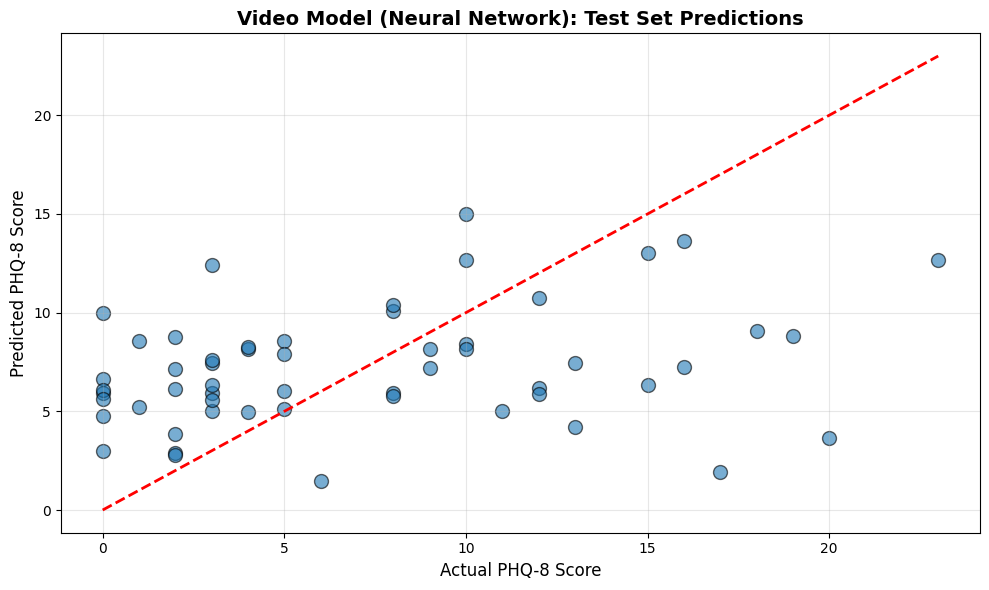

In [ ]:
# Train video models and select best
video_model, video_model_name, video_test_metrics = train_video_models(
    X_train_video_scaled, y_train_video,
    X_test_video_scaled, y_test_video
)

# Save video file IDs for alignment check
ids_train_video_global = ids_train_video
ids_test_video_global = ids_test_video

#Textual Model

Total text samples: 275
Total file IDs tracked: 275
Train samples: 220, Test samples: 55
File IDs in train set: 220, in test set: 55

TRAINING TEXT MODELS

[1/4] Training Random Forest (TF-IDF)...
[2/4] Training Gradient Boosting (TF-IDF)...
[3/4] Training CNN...
[4/4] Training LSTM...

TEXT MODEL COMPARISON

Random Forest (TF-IDF):
  Train MAE: 1.6809 | Test MAE: 3.6607
  Train R²: 0.8829 | Test R²: 0.4450

Gradient Boosting (TF-IDF):
  Train MAE: 0.0882 | Test MAE: 3.6697
  Train R²: 0.9997 | Test R²: 0.4299

CNN:
  Train MAE: 1.2429 | Test MAE: 3.9125
  Train R²: 0.9187 | Test R²: 0.3410

LSTM:
  Train MAE: 5.0432 | Test MAE: 5.1527
  Train R²: 0.0067 | Test R²: -0.0043

 Selected from 3 models with positive R²

 Best Text Model: Random Forest (TF-IDF)
MAE: 3.6607
MSE: 20.2834
RMSE: 4.5037
R2: 0.4450


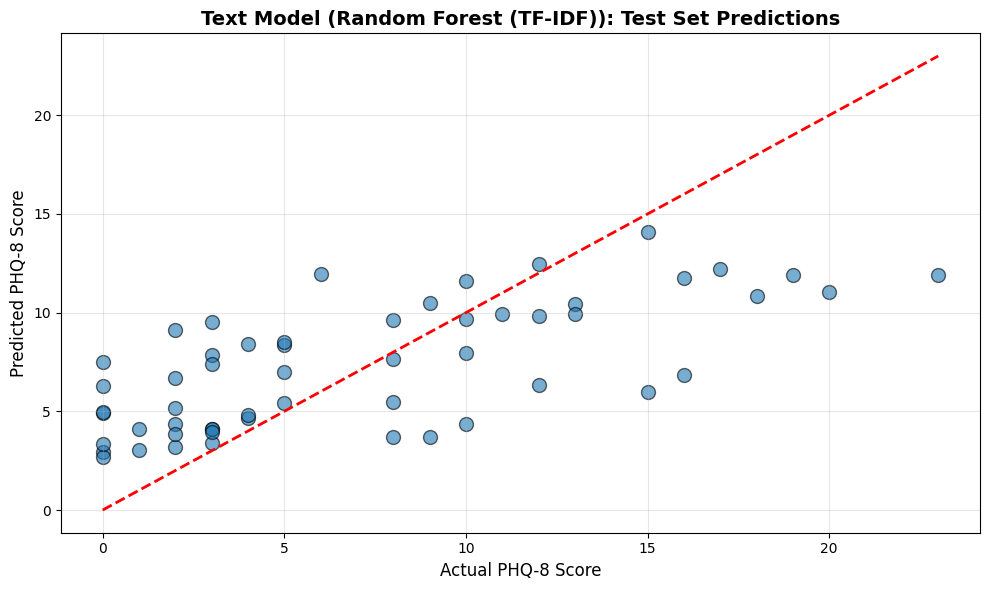

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, GlobalAveragePooling1D, Conv1D, MaxPooling1D
from tensorflow.keras import regularizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import matplotlib.pyplot as plt

# Parameters
max_vocab_size = 5000
max_seq_len = 200  # Reduced
embedding_dim = 50  # Reduced

# Load text files
def load_texts_from_folder(folder_path):
    texts = []
    file_ids = []
    file_names = sorted(os.listdir(folder_path))
    for fname in file_names:
        if fname.endswith('.txt'):
            # Extract file ID from filename
            file_id = fname.split('_')[0]
            with open(os.path.join(folder_path, fname), 'r', encoding='utf-8') as f:
                texts.append(f.read())
                file_ids.append(file_id)
    return texts, file_ids

folder_path = "/content/drive/MyDrive/transcript_summaries"
texts, text_file_ids = load_texts_from_folder(folder_path)

phq8_scores = [2, 3, 4, 0, 6, 7, 0, 4, 22, 15, 4, 21, 2, 7, 1, 2, 6, 8, 3, 13, 11, 20, 5, 1, 5, 10, 2, 4, 4, 1, 12, 8, 18, 5, 5, 12, 7, 10, 15, 11, 1, 7, 9, 11, 15, 23, 16, 20, 5, 11, 14, 10, 11, 18, 10, 10, 7, 7, 13, 4, 0, 20, 0, 0, 12, 0, 19, 7, 0, 0, 9, 13, 9, 2, 5, 12, 16, 1, 2, 10, 16, 0, 7, 15, 8, 11, 2, 17, 14, 9, 9, 1, 2, 7, 5, 5, 7, 7, 9, 11, 0, 0, 17, 2, 3, 0, 10, 12, 0, 12, 10, 16, 3, 3, 7, 10, 3, 3, 10, 12, 0, 3, 6, 20, 5, 0, 1, 3, 2, 1, 10, 2, 8, 0, 0, 2, 1, 19, 18, 6, 1, 7, 1, 0, 1, 18, 2, 9, 4, 1, 17, 1, 1, 6, 3, 5, 16, 17, 9, 0, 0, 2, 9, 0, 4, 3, 3, 0, 3, 0, 4, 6, 3, 2, 1, 7, 1, 7, 1, 15, 9, 2, 4, 0, 0, 3, 2, 8, 0, 5, 0, 13, 4, 12, 2, 5, 7, 2, 0, 1, 3, 12, 4, 6, 0, 0, 9, 22, 2, 0, 3, 0, 0, 0, 1, 10, 2, 9, 15, 16, 19, 17, 17, 19, 3, 5, 7, 4, 6, 12, 8, 0, 11, 16, 2, 19, 2, 9, 2, 5, 3, 7, 0, 13, 0, 12, 8, 22, 12, 6, 18, 7, 19, 13, 11, 0, 3, 7, 13, 5, 19, 16, 0, 8, 20, 1, 0, 10, 7, 0, 0, 7, 15, 1, 3]

print(f"Total text samples: {len(texts)}")
assert len(texts) == len(phq8_scores), "Mismatch between texts and scores"
print(f"Total file IDs tracked: {len(text_file_ids)}")

# Tokenize for neural models
tokenizer = Tokenizer(num_words=max_vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
padded_sequences = pad_sequences(sequences, maxlen=max_seq_len, padding='post', truncating='post')

# TF-IDF for traditional ML models
tfidf_vectorizer = TfidfVectorizer(max_features=500, ngram_range=(1, 2))
tfidf_features = tfidf_vectorizer.fit_transform(texts).toarray()

# 80-20 split - include file IDs to track which samples are in test set
X_train_text, X_test_text, y_train_text, y_test_text, ids_train_text, ids_test_text = train_test_split(
    padded_sequences, phq8_scores, text_file_ids, test_size=0.2, random_state=42
)

X_train_tfidf, X_test_tfidf = train_test_split(
    tfidf_features, test_size=0.2, random_state=42
)[0:2]

# Convert to proper numpy arrays with correct dtype
X_train_text = np.array(X_train_text, dtype=np.int32)
X_test_text = np.array(X_test_text, dtype=np.int32)
y_train_text = np.array(y_train_text, dtype=np.float32)
y_test_text = np.array(y_test_text, dtype=np.float32)

print(f"Train samples: {len(X_train_text)}, Test samples: {len(X_test_text)}")
print(f"File IDs in train set: {len(ids_train_text)}, in test set: {len(ids_test_text)}")

def calculate_text_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

def plot_text_predictions(y_true, y_pred, title="Text Model: Predictions vs Actual"):
    plt.figure(figsize=(10, 6))
    plt.scatter(y_true, y_pred, alpha=0.6, s=100, edgecolors='k')
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--', lw=2)
    plt.xlabel('Actual PHQ-8 Score', fontsize=12)
    plt.ylabel('Predicted PHQ-8 Score', fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("\n" + "="*60)
print("TRAINING TEXT MODELS")
print("="*60)

models = {}
results = {}

# 1. Random Forest with TF-IDF
print("\n[1/4] Training Random Forest (TF-IDF)...")
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_tfidf, y_train_text)
models['Random Forest (TF-IDF)'] = rf_model

# 2. Gradient Boosting with TF-IDF
print("[2/4] Training Gradient Boosting (TF-IDF)...")
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    min_samples_split=5,
    subsample=0.8,
    random_state=42
)
gb_model.fit(X_train_tfidf, y_train_text)
models['Gradient Boosting (TF-IDF)'] = gb_model

# 3. CNN Text Model
print("[3/4] Training CNN...")
cnn_model = Sequential([
    Embedding(max_vocab_size, embedding_dim),
    Conv1D(64, 5, activation='relu'),
    MaxPooling1D(pool_size=4),
    Conv1D(32, 3, activation='relu'),
    GlobalAveragePooling1D(),
    Dropout(0.5),
    Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.3),
    Dense(1)
])

cnn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop_cnn = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True, verbose=0
)

history_cnn = cnn_model.fit(
    X_train_text, y_train_text,
    validation_data=(X_test_text, y_test_text),
    epochs=20,
    batch_size=16,
    callbacks=[early_stop_cnn],
    verbose=0
)
models['CNN'] = cnn_model

# 4. Simple LSTM
print("[4/4] Training LSTM...")
lstm_model = Sequential([
    Embedding(max_vocab_size, embedding_dim),
    LSTM(32, dropout=0.3, recurrent_dropout=0.2, kernel_regularizer=regularizers.l2(0.01)),
    Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.3),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop_lstm = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True, verbose=0
)

history_lstm = lstm_model.fit(
    X_train_text, y_train_text,
    validation_data=(X_test_text, y_test_text),
    epochs=20,
    batch_size=16,
    callbacks=[early_stop_lstm],
    verbose=0
)
models['LSTM'] = lstm_model

# Evaluate all models
print("\n" + "="*60)
print("TEXT MODEL COMPARISON")
print("="*60)

for name, model in models.items():
    if 'TF-IDF' in name:
        y_pred_train = model.predict(X_train_tfidf)
        y_pred_test = model.predict(X_test_tfidf)
    else:
        y_pred_train = model.predict(X_train_text, verbose=0).flatten()
        y_pred_test = model.predict(X_test_text, verbose=0).flatten()

    train_metrics = calculate_text_metrics(y_train_text, y_pred_train)
    test_metrics = calculate_text_metrics(y_test_text, y_pred_test)

    results[name] = {
        'train': train_metrics,
        'test': test_metrics,
        'y_pred_test': y_pred_test,
        'y_test': y_test_text,
        'uses_tfidf': 'TF-IDF' in name
    }

    print(f"\n{name}:")
    print(f"  Train MAE: {train_metrics['MAE']:.4f} | Test MAE: {test_metrics['MAE']:.4f}")
    print(f"  Train R²: {train_metrics['R2']:.4f} | Test R²: {test_metrics['R2']:.4f}")

# Select best model: prioritize positive R², then lowest MAE
models_with_positive_r2 = {name: res for name, res in results.items() if res['test']['R2'] > 0}

if models_with_positive_r2:
    # Choose model with best (lowest) MAE among those with positive R²
    best_model_name = min(models_with_positive_r2.keys(),
                         key=lambda x: models_with_positive_r2[x]['test']['MAE'])
    print(f"\n Selected from {len(models_with_positive_r2)} models with positive R²")
else:
    # Fallback: if all R² are negative, choose the one closest to 0 (least bad)
    best_model_name = max(results.keys(), key=lambda x: results[x]['test']['R2'])
    print(f"\n WARNING: All models have negative R² (worse than mean prediction)")
    print(f"   Selecting model with R² closest to 0 (least bad)")

best_model = models[best_model_name]
best_metrics = results[best_model_name]['test']
uses_tfidf = results[best_model_name]['uses_tfidf']

print(f"\n{'='*60}")
print(f" Best Text Model: {best_model_name}")
print(f"{'='*60}")
for metric, value in best_metrics.items():
    print(f"{metric}: {value:.4f}")

# Plot best model
plot_text_predictions(
    results[best_model_name]['y_test'],
    results[best_model_name]['y_pred_test'],
    f"Text Model ({best_model_name}): Test Set Predictions"
)

# Prediction function
def predict_phq8_score(model, tokenizer_or_vectorizer, filepath, max_seq_len, uses_tfidf=False):
    with open(filepath, 'r', encoding='utf-8') as f:
        text = f.read()

    if uses_tfidf:
        features = tokenizer_or_vectorizer.transform([text]).toarray()
        pred = model.predict(features)
    else:
        seq = tokenizer_or_vectorizer.texts_to_sequences([text])
        padded = pad_sequences(seq, maxlen=max_seq_len, padding='post', truncating='post')
        pred = model.predict(padded, verbose=0)

    return pred[0] if uses_tfidf else pred[0][0]

text_test_metrics = best_metrics
text_model = best_model
text_model_name = best_model_name
text_uses_tfidf = uses_tfidf

# Save appropriate preprocessor
if text_uses_tfidf:
    text_preprocessor = tfidf_vectorizer
else:
    text_preprocessor = tokenizer


INDIVIDUAL MODEL PERFORMANCE COMPARISON

                         Model  Test MAE  Test RMSE  Test R²
    Audio (Gradient Boosting)  4.856229   6.262037 0.022940
       Video (Neural Network)  4.775377   5.890644 0.050592
Text (Random Forest (TF-IDF))  3.660716   4.503714 0.445031


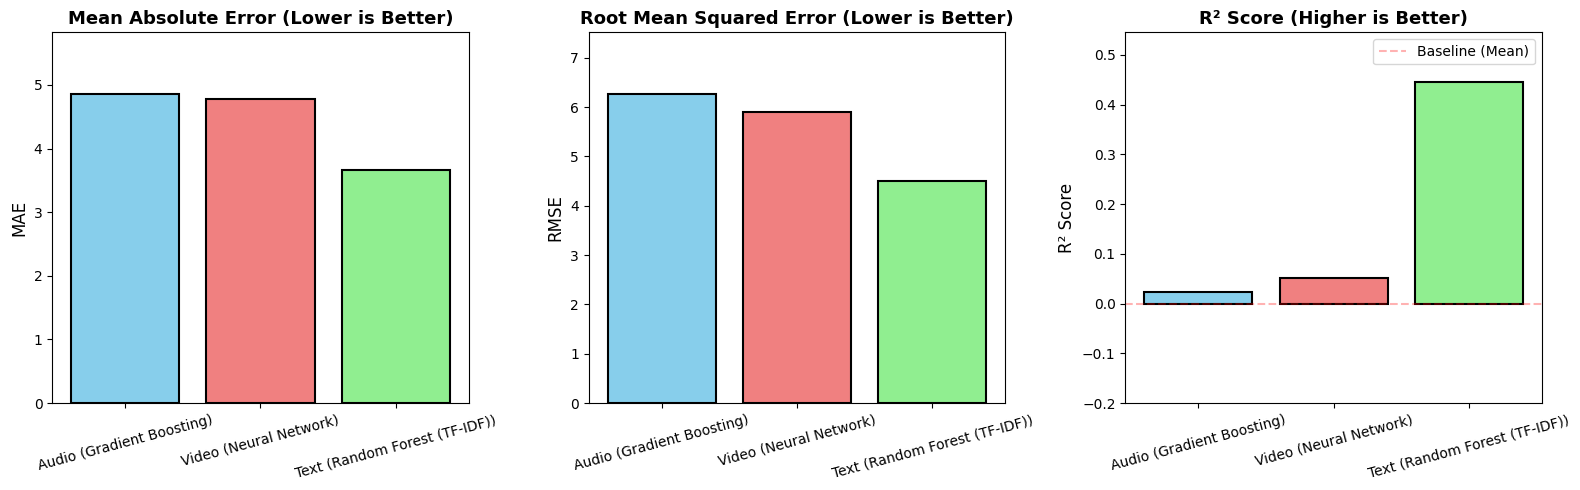


 Best Individual Model: Text (Random Forest (TF-IDF))
   MAE: 3.6607
   RMSE: 4.5037
   R²: 0.4450


In [ ]:
# ============================================
# COMPREHENSIVE MODEL COMPARISON
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

print("\n" + "="*70)
print("INDIVIDUAL MODEL PERFORMANCE COMPARISON")
print("="*70)

comparison_data = {
    'Model': [
        f'Audio ({audio_model_name})',
        f'Video ({video_model_name})',
        f'Text ({text_model_name})'
    ],
    'Test MAE': [
        audio_test_metrics['MAE'],
        video_test_metrics['MAE'],
        text_test_metrics['MAE']
    ],
    'Test RMSE': [
        audio_test_metrics['RMSE'],
        video_test_metrics['RMSE'],
        text_test_metrics['RMSE']
    ],
    'Test R²': [
        audio_test_metrics['R2'],
        video_test_metrics['R2'],
        text_test_metrics['R2']
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n", comparison_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = comparison_df['Model']
mae_values = comparison_df['Test MAE']
rmse_values = comparison_df['Test RMSE']
r2_values = comparison_df['Test R²']

colors = ['skyblue', 'lightcoral', 'lightgreen']

axes[0].bar(models, mae_values, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('MAE', fontsize=12)
axes[0].set_title('Mean Absolute Error (Lower is Better)', fontsize=13, fontweight='bold')
axes[0].set_ylim([0, max(mae_values) * 1.2])
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(models, rmse_values, color=colors, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('RMSE', fontsize=12)
axes[1].set_title('Root Mean Squared Error (Lower is Better)', fontsize=13, fontweight='bold')
axes[1].set_ylim([0, max(rmse_values) * 1.2])
axes[1].tick_params(axis='x', rotation=15)

axes[2].bar(models, r2_values, color=colors, edgecolor='black', linewidth=1.5)
axes[2].set_ylabel('R² Score', fontsize=12)
axes[2].set_title('R² Score (Higher is Better)', fontsize=13, fontweight='bold')
axes[2].axhline(y=0, color='r', linestyle='--', alpha=0.3, label='Baseline (Mean)')
min_r2 = min(r2_values)
max_r2 = max(r2_values)
axes[2].set_ylim([min(min_r2 - 0.1, -0.2), max(max_r2 + 0.1, 0.5)])
axes[2].tick_params(axis='x', rotation=15)
axes[2].legend()

plt.tight_layout()
plt.show()

# Determine best individual model
best_model_idx = comparison_df['Test MAE'].idxmin()
best_model = comparison_df.loc[best_model_idx, 'Model']
print(f"\n Best Individual Model: {best_model}")
print(f"   MAE: {comparison_df.loc[best_model_idx, 'Test MAE']:.4f}")
print(f"   RMSE: {comparison_df.loc[best_model_idx, 'Test RMSE']:.4f}")
print(f"   R²: {comparison_df.loc[best_model_idx, 'Test R²']:.4f}")

# Check for negative R²
if any(r2_values < 0):
    print("\n  WARNING: Negative R² scores detected!")
    print("   This means the model performs worse than predicting the mean.")
    print("   Consider:")
    print("   - Collecting more data")
    print("   - Feature engineering")
    print("   - Using simpler baseline models")

In [ ]:
# ============================================
# DATA ALIGNMENT VERIFICATION
# ============================================

print("\n" + "="*80)
print("DATA ALIGNMENT VERIFICATION ACROSS MODALITIES")
print("="*80)

# Check if all required variables exist
required_vars = {
    'ids_test': 'Audio test IDs',
    'ids_train': 'Audio train IDs',
    'ids_test_video': 'Video test IDs',
    'ids_train_video': 'Video train IDs',
    'ids_test_text': 'Text test IDs',
    'ids_train_text': 'Text train IDs'
}

missing_vars = []
for var_name, description in required_vars.items():
    if var_name not in globals():
        missing_vars.append(f"  - {var_name} ({description})")

if missing_vars:
    print("\n ERROR: Required variables not found!")
    print("   Please run the following cells first:")
    print("   1. Audio model training cell (defines ids_test, ids_train)")
    print("   2. Video model training cell (defines ids_test_video, ids_train_video)")
    print("   3. Text model training cell (defines ids_test_text, ids_train_text)")
    print("\n   Missing variables:")
    for var in missing_vars:
        print(var)
    raise RuntimeError("Cannot perform alignment check without all file ID variables")

# Check if all modalities have the same test file IDs
print("\n Checking file ID alignment across modalities...")

# Convert to sets for comparison
audio_test_ids_set = set(ids_test)
video_test_ids_set = set(ids_test_video)
text_test_ids_set = set(ids_test_text)

audio_train_ids_set = set(ids_train)
video_train_ids_set = set(ids_train_video)
text_train_ids_set = set(ids_train_text)

# Check test set alignment
print("\n Test Set Alignment:")
print(f"  Audio test IDs: {len(audio_test_ids_set)}")
print(f"  Video test IDs: {len(video_test_ids_set)}")
print(f"  Text test IDs:  {len(text_test_ids_set)}")

# Find common test IDs across all modalities
common_test_ids = audio_test_ids_set & video_test_ids_set & text_test_ids_set
print(f"\n Common test IDs across all modalities: {len(common_test_ids)}")

# Check for mismatches
audio_only = audio_test_ids_set - video_test_ids_set - text_test_ids_set
video_only = video_test_ids_set - audio_test_ids_set - text_test_ids_set
text_only = text_test_ids_set - audio_test_ids_set - video_test_ids_set

if audio_only:
    print(f"\n  WARNING: {len(audio_only)} IDs only in audio test set: {sorted(list(audio_only))[:10]}")
if video_only:
    print(f"  WARNING: {len(video_only)} IDs only in video test set: {sorted(list(video_only))[:10]}")
if text_only:
    print(f"  WARNING: {len(text_only)} IDs only in text test set: {sorted(list(text_only))[:10]}")

# Check train set alignment
print("\n Train Set Alignment:")
print(f"  Audio train IDs: {len(audio_train_ids_set)}")
print(f"  Video train IDs: {len(video_train_ids_set)}")
print(f"  Text train IDs:  {len(text_train_ids_set)}")

common_train_ids = audio_train_ids_set & video_train_ids_set & text_train_ids_set
print(f"\n Common train IDs across all modalities: {len(common_train_ids)}")

# CRITICAL: Check if the split was deterministic (same random_state=42)
# All modalities should have used the same train_test_split with random_state=42
if len(common_test_ids) == len(audio_test_ids_set) == len(video_test_ids_set) == len(text_test_ids_set):
    print("\n PERFECT ALIGNMENT: All test sets have identical file IDs!")
    print("    The fusion model will work correctly with aligned data.")
else:
    print("\n ALIGNMENT ISSUE DETECTED!")
    print("    Different modalities have different test samples.")
    print("    This can happen if:")
    print("    1. Audio files were skipped due to dimension mismatches")
    print("    2. Some modalities have missing or corrupted files")
    print("    3. Different random_state was used in train_test_split")
    print("\n    RECOMMENDATION: Only use samples that appear in all three modalities")
    print(f"    Safe test samples to use: {len(common_test_ids)}")

# Save common IDs for fusion model to use
print(f"\n Saving common test IDs for fusion model evaluation...")
common_test_ids_list = sorted(list(common_test_ids))
print(f"   First 10 common test IDs: {common_test_ids_list[:10]}")

print("\n" + "="*80)


DATA ALIGNMENT VERIFICATION ACROSS MODALITIES

 Checking file ID alignment across modalities...

 Test Set Alignment:
  Audio test IDs: 44
  Video test IDs: 55
  Text test IDs:  55

 Common test IDs across all modalities: 17


 Train Set Alignment:
  Audio train IDs: 175
  Video train IDs: 220
  Text train IDs:  220

 Common train IDs across all modalities: 148

 ALIGNMENT ISSUE DETECTED!
    Different modalities have different test samples.
    This can happen if:
    1. Audio files were skipped due to dimension mismatches
    2. Some modalities have missing or corrupted files
    3. Different random_state was used in train_test_split

    RECOMMENDATION: Only use samples that appear in all three modalities
    Safe test samples to use: 17

 Saving common test IDs for fusion model evaluation...
   First 10 common test IDs: [np.str_('309'), np.str_('315'), np.str_('325'), np.str_('330'), np.str_('346'), np.str_('367'), np.str_('374'), np.str_('376'), np.str_('387'), np.str_('407')]



#FusionModel


In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

class ImprovedMultimodalFusionModel:
    def __init__(self, text_model, text_preprocessor, max_seq_len, text_uses_tfidf,
                 audio_model, audio_scaler, audio_feature_dim, audio_is_nn,
                 video_model, video_scaler, video_is_nn,
                 weights=(0.4, 0.3, 0.3)):

        self.text_model = text_model
        self.text_preprocessor = text_preprocessor
        self.max_seq_len = max_seq_len
        self.text_uses_tfidf = text_uses_tfidf

        self.audio_model = audio_model
        self.audio_scaler = audio_scaler
        self.audio_feature_dim = audio_feature_dim
        self.audio_is_nn = audio_is_nn

        self.video_model = video_model
        self.video_scaler = video_scaler
        self.video_is_nn = video_is_nn

        self.base_weights = weights

    def predict_text(self, text_path):
        try:
            with open(text_path, 'r', encoding='utf-8') as f:
                text = f.read()

            if self.text_uses_tfidf:
                features = self.text_preprocessor.transform([text]).toarray()
                pred = self.text_model.predict(features)
                return float(pred[0])
            else:
                seq = self.text_preprocessor.texts_to_sequences([text])
                from tensorflow.keras.preprocessing.sequence import pad_sequences
                padded = pad_sequences(seq, maxlen=self.max_seq_len, padding='post', truncating='post')
                pred = self.text_model.predict(padded, verbose=0)
                return float(pred[0][0])
        except Exception as e:
            print(f"[Text Error] {text_path} — {e}")
            return None

    def predict_audio(self, audio_path):
        try:
            df = pd.read_csv(audio_path).apply(pd.to_numeric, errors='coerce').fillna(0)

            # Aggregate features
            features_mean = df.mean().values
            features_std = df.std().values
            features_min = df.min().values
            features_max = df.max().values
            features = np.concatenate([features_mean, features_std, features_min, features_max])

            # Scale
            features_scaled = self.audio_scaler.transform(features.reshape(1, -1))

            # Predict
            if self.audio_is_nn:
                pred = self.audio_model.predict(features_scaled, verbose=0)
                return float(pred[0][0])
            else:
                pred = self.audio_model.predict(features_scaled)
                return float(pred[0])
        except Exception as e:
            print(f"[Audio Error] {audio_path} — {e}")
            return None

    def predict_video(self, video_path):
        try:
            # Aggregate video features
            features = load_and_aggregate_video_features([video_path], confidence_threshold=0.8)
            features_scaled = self.video_scaler.transform(features)

            if self.video_is_nn:
                pred = self.video_model.predict(features_scaled, verbose=0)
                return float(pred[0][0])
            else:
                pred = self.video_model.predict(features_scaled)
                return float(pred[0])
        except Exception as e:
            print(f"[Video Error] {video_path} — {e}")
            return None

    def predict(self, text_path, audio_path, video_path):
        """Predict with adaptive weight adjustment"""
        text_score = self.predict_text(text_path)
        audio_score = self.predict_audio(audio_path)
        video_score = self.predict_video(video_path)

        scores = [text_score, audio_score, video_score]
        active_weights = [w if s is not None else 0.0 for w, s in zip(self.base_weights, scores)]

        total = sum(active_weights)
        if total == 0:
            return None

        normalized_weights = [w / total for w in active_weights]
        fused_score = sum(w * s for w, s in zip(normalized_weights, scores) if s is not None)

        return fused_score

    def evaluate_on_test_set(self, text_dir, audio_dir, video_dir, test_indices, all_file_ids, true_scores):
        """Evaluate fusion model on test set"""
        predictions = []
        actuals = []

        for idx in test_indices:
            file_id = all_file_ids[idx]
            true_score = true_scores[idx]

            text_path = os.path.join(text_dir, f"{file_id}_Transcript_summary.txt")
            audio_path = os.path.join(audio_dir, f"{file_id}_BoAW_openSMILE_2.3.0_MFCC.csv")
            video_path = os.path.join(video_dir, f"{file_id}_OpenFace2.1.0_Pose_gaze_AUs.csv")

            pred_score = self.predict(text_path, audio_path, video_path)

            if pred_score is not None:
                predictions.append(pred_score)
                actuals.append(true_score)

        if len(predictions) == 0:
            return None

        metrics = {
            'MAE': mean_absolute_error(actuals, predictions),
            'MSE': mean_squared_error(actuals, predictions),
            'RMSE': np.sqrt(mean_squared_error(actuals, predictions)),
            'R2': r2_score(actuals, predictions)
        }

        return metrics, actuals, predictions

Evaluating fusion model on 55 test samples...

TESTING DIFFERENT FUSION WEIGHT COMBINATIONS
[Video Error] /content/video/330_OpenFace2.1.0_Pose_gaze_AUs.csv — setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (2, 1) + inhomogeneous part.
[Video Error] /content/video/442_OpenFace2.1.0_Pose_gaze_AUs.csv — setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (2, 1) + inhomogeneous part.
[Audio Error] /content/audio_filtered/606_BoAW_openSMILE_2.3.0_MFCC.csv — X has 4 features, but StandardScaler is expecting 408 features as input.
[Video Error] /content/video/606_OpenFace2.1.0_Pose_gaze_AUs.csv — setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (2, 1) + inhomogeneous part.
[Video Error] /content/video/429_OpenFace2.1.0_Pose_gaze_AUs.csv — setting an

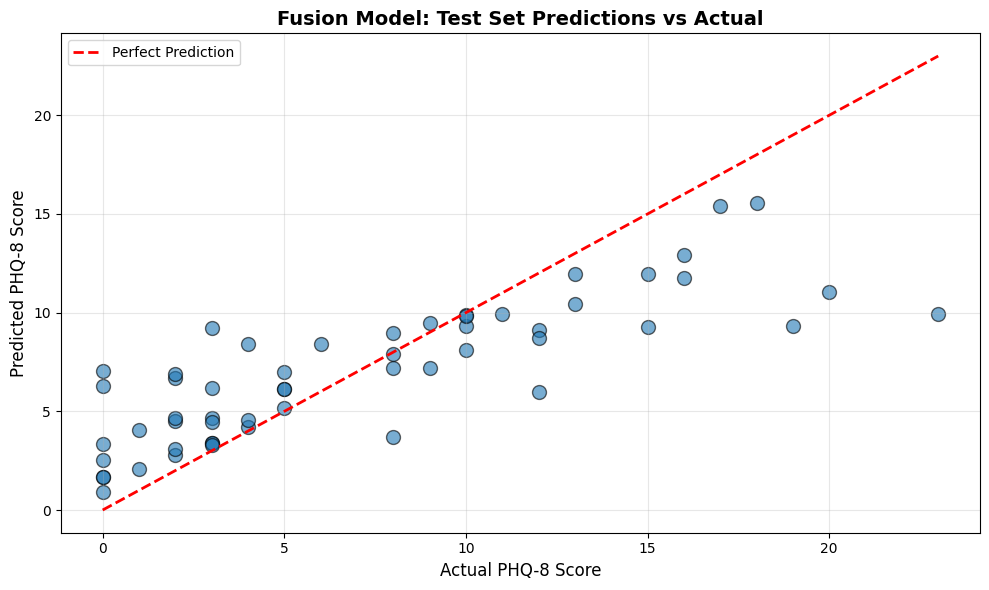

In [ ]:
# Test fusion model with learned weights optimization
import os
from sklearn.model_selection import train_test_split

# Get all file IDs and prepare test set
text_dir = "/content/drive/MyDrive/transcript_summaries/"
audio_dir = "/content/audio_filtered/"
video_dir = "/content/video/"

all_files = sorted([f for f in os.listdir(text_dir) if f.endswith('.txt')])
all_file_ids = [f.split('_')[0] for f in all_files]

phq8_all = [2, 3, 4, 0, 6, 7, 0, 4, 22, 15, 4, 21, 2, 7, 1, 2, 6, 8, 3, 13, 11, 20, 5, 1, 5, 10, 2, 4, 4, 1, 12, 8, 18, 5, 5, 12, 7, 10, 15, 11, 1, 7, 9, 11, 15, 23, 16, 20, 5, 11, 14, 10, 11, 18, 10, 10, 7, 7, 13, 4, 0, 20, 0, 0, 12, 0, 19, 7, 0, 0, 9, 13, 9, 2, 5, 12, 16, 1, 2, 10, 16, 0, 7, 15, 8, 11, 2, 17, 14, 9, 9, 1, 2, 7, 5, 5, 7, 7, 9, 11, 0, 0, 17, 2, 3, 0, 10, 12, 0, 12, 10, 16, 3, 3, 7, 10, 3, 3, 10, 12, 0, 3, 6, 20, 5, 0, 1, 3, 2, 1, 10, 2, 8, 0, 0, 2, 1, 19, 18, 6, 1, 7, 1, 0, 1, 18, 2, 9, 4, 1, 17, 1, 1, 6, 3, 5, 16, 17, 9, 0, 0, 2, 9, 0, 4, 3, 3, 0, 3, 0, 4, 6, 3, 2, 1, 7, 1, 7, 1, 15, 9, 2, 4, 0, 0, 3, 2, 8, 0, 5, 0, 13, 4, 12, 2, 5, 7, 2, 0, 1, 3, 12, 4, 6, 0, 0, 9, 22, 2, 0, 3, 0, 0, 0, 1, 10, 2, 9, 15, 16, 19, 17, 17, 19, 3, 5, 7, 4, 6, 12, 8, 0, 11, 16, 2, 19, 2, 9, 2, 5, 3, 7, 0, 13, 0, 12, 8, 22, 12, 6, 18, 7, 19, 13, 11, 0, 3, 7, 13, 5, 19, 16, 0, 8, 20, 1, 0, 10, 7, 0, 0, 7, 15, 1, 3]

# Get train/test indices (same split as individual models)
indices = list(range(len(all_file_ids)))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)

print(f"Evaluating fusion model on {len(test_idx)} test samples...")

# Determine if models are neural networks
audio_is_nn = 'Neural' in audio_model_name
video_is_nn = 'Neural' in video_model_name

# Try different weight combinations
weight_configs = [
    (0.33, 0.33, 0.34),  # Equal weights
    (0.5, 0.25, 0.25),   # Text dominant
    (0.25, 0.5, 0.25),   # Audio dominant
    (0.25, 0.25, 0.5),   # Video dominant
    (0.4, 0.4, 0.2),     # Text+Audio
    (0.4, 0.2, 0.4),     # Text+Video
    (0.2, 0.4, 0.4),     # Audio+Video
]

best_mae = float('inf')
best_weights = None
best_metrics = None

print("\n" + "="*60)
print("TESTING DIFFERENT FUSION WEIGHT COMBINATIONS")
print("="*60)

for weights in weight_configs:
    fusion_model = ImprovedMultimodalFusionModel(
        text_model=text_model,
        text_preprocessor=text_preprocessor,
        max_seq_len=max_seq_len,
        text_uses_tfidf=text_uses_tfidf,
        audio_model=audio_model,
        audio_scaler=audio_scaler,
        audio_feature_dim=audio_feature_dim,
        audio_is_nn=audio_is_nn,
        video_model=video_model,
        video_scaler=scaler_video,
        video_is_nn=video_is_nn,
        weights=weights
    )

    result = fusion_model.evaluate_on_test_set(
        text_dir, audio_dir, video_dir,
        test_idx, all_file_ids, phq8_all
    )

    if result is not None:
        metrics, _, _ = result
        print(f"\nWeights (Text, Audio, Video): {weights}")
        print(f"  MAE: {metrics['MAE']:.4f}, RMSE: {metrics['RMSE']:.4f}, R²: {metrics['R2']:.4f}")

        if metrics['MAE'] < best_mae:
            best_mae = metrics['MAE']
            best_weights = weights
            best_metrics = metrics

print("\n" + "="*60)
print(f" BEST FUSION WEIGHTS: {best_weights}")
print("="*60)
for metric, value in best_metrics.items():
    print(f"{metric}: {value:.4f}")

# Create final fusion model with best weights
final_fusion_model = ImprovedMultimodalFusionModel(
    text_model=text_model,
    text_preprocessor=text_preprocessor,
    max_seq_len=max_seq_len,
    text_uses_tfidf=text_uses_tfidf,
    audio_model=audio_model,
    audio_scaler=audio_scaler,
    audio_feature_dim=audio_feature_dim,
    audio_is_nn=audio_is_nn,
    video_model=video_model,
    video_scaler=scaler_video,
    video_is_nn=video_is_nn,
    weights=best_weights
)

fusion_result = final_fusion_model.evaluate_on_test_set(
    text_dir, audio_dir, video_dir,
    test_idx, all_file_ids, phq8_all
)

fusion_test_metrics, y_true_fusion, y_pred_fusion = fusion_result

# Plot fusion results
plt.figure(figsize=(10, 6))
plt.scatter(y_true_fusion, y_pred_fusion, alpha=0.6, s=100, edgecolors='k')
plt.plot([min(y_true_fusion), max(y_true_fusion)],
         [min(y_true_fusion), max(y_true_fusion)], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual PHQ-8 Score', fontsize=12)
plt.ylabel('Predicted PHQ-8 Score', fontsize=12)
plt.title('Fusion Model: Test Set Predictions vs Actual', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# SINGLE SAMPLE PREDICTION EXAMPLE
# ============================================

# Example: Predict on a single sample
sample_file_id = "718"

text_path = f'/content/drive/MyDrive/transcript_summaries/{sample_file_id}_Transcript_summary.txt'
audio_path = f'/content/audio_filtered/{sample_file_id}_BoAW_openSMILE_2.3.0_MFCC.csv'
video_path = f'/content/video/{sample_file_id}_OpenFace2.1.0_Pose_gaze_AUs.csv'

print(f"\n{'='*60}")
print(f"PREDICTING PHQ-8 SCORE FOR FILE ID: {sample_file_id}")
print(f"{'='*60}")

# Individual predictions
text_pred = final_fusion_model.predict_text(text_path)
audio_pred = final_fusion_model.predict_audio(audio_path)
video_pred = final_fusion_model.predict_video(video_path)
fusion_pred = final_fusion_model.predict(text_path, audio_path, video_path)

# Format predictions with error handling
def format_prediction(pred, modality_name):
    if pred is None:
        return f" {modality_name} Model: FAILED (incompatible features or missing file)"
    else:
        return f" {modality_name} Model Prediction: {pred:.2f}"

print(f"\n{format_prediction(text_pred, '📝 Text')}")
print(f"{format_prediction(audio_pred, '🎵 Audio')}")
print(f"{format_prediction(video_pred, '🎥 Video')}")

if fusion_pred is not None:
    print(f"\n Fusion Model Prediction: {fusion_pred:.2f}")
    print(f"   (Weighted combination of available modalities)")
else:
    print(f"\n Fusion Model Prediction: FAILED")
    print(f"   (All modalities failed - cannot make prediction)")

print(f"{'='*60}")

# Summary of prediction status
available_modalities = sum([pred is not None for pred in [text_pred, audio_pred, video_pred]])
print(f"\n Prediction Summary:")
print(f"   Available modalities: {available_modalities}/3")
if available_modalities > 0 and fusion_pred is not None:
    print(f"   Fusion used adaptive weighting to combine available predictions")
elif available_modalities == 0:
    print(f"     All modalities failed - this file may be corrupted or incompatible")


PREDICTING PHQ-8 SCORE FOR FILE ID: 718
[Audio Error] /content/audio_filtered/718_BoAW_openSMILE_2.3.0_MFCC.csv — X has 4 features, but StandardScaler is expecting 408 features as input.
[Video Error] /content/video/718_OpenFace2.1.0_Pose_gaze_AUs.csv — setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (2, 1) + inhomogeneous part.
[Audio Error] /content/audio_filtered/718_BoAW_openSMILE_2.3.0_MFCC.csv — X has 4 features, but StandardScaler is expecting 408 features as input.
[Video Error] /content/video/718_OpenFace2.1.0_Pose_gaze_AUs.csv — setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (2, 1) + inhomogeneous part.

 📝 Text Model Prediction: 3.65
 🎵 Audio Model: FAILED (incompatible features or missing file)
 🎥 Video Model: FAILED (incompatible features or missing file)

 Fusion Model Prediction: 3.65
   (Weighted combin

Evaluating fusion model on 55 test samples...

TESTING DIFFERENT FUSION WEIGHT COMBINATIONS
[Video Error] /content/video/330_OpenFace2.1.0_Pose_gaze_AUs.csv — setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (2, 1) + inhomogeneous part.
[Video Error] /content/video/442_OpenFace2.1.0_Pose_gaze_AUs.csv — setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (2, 1) + inhomogeneous part.
[Audio Error] /content/audio_filtered/606_BoAW_openSMILE_2.3.0_MFCC.csv — X has 4 features, but StandardScaler is expecting 408 features as input.
[Video Error] /content/video/606_OpenFace2.1.0_Pose_gaze_AUs.csv — setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (2, 1) + inhomogeneous part.
[Video Error] /content/video/429_OpenFace2.1.0_Pose_gaze_AUs.csv — setting an

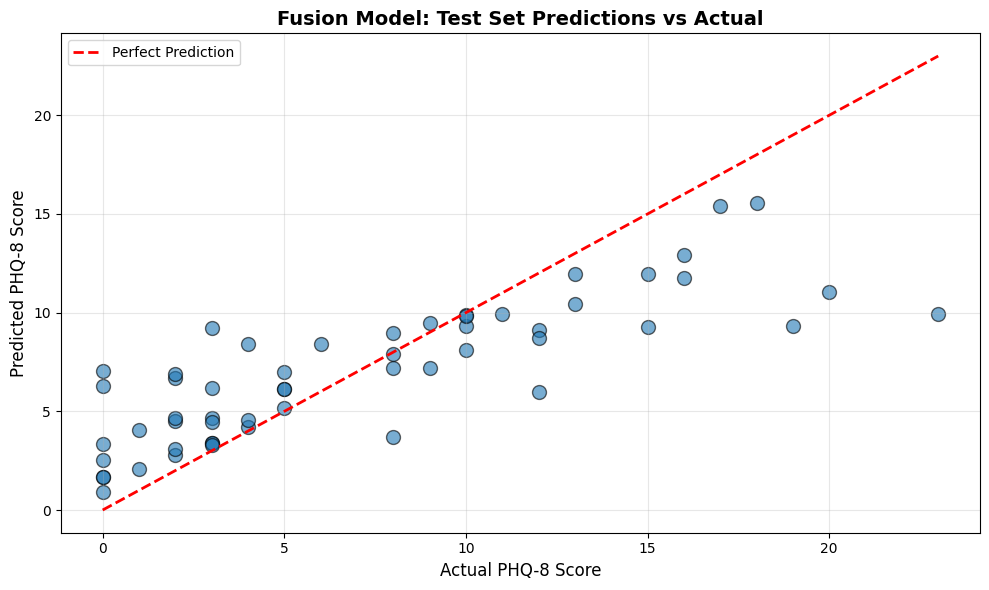

In [ ]:
# Test fusion model with learned weights optimization
import os
from sklearn.model_selection import train_test_split

# Get all file IDs and prepare test set
text_dir = "/content/drive/MyDrive/transcript_summaries/"
audio_dir = "/content/audio_filtered/"
video_dir = "/content/video/"

all_files = sorted([f for f in os.listdir(text_dir) if f.endswith('.txt')])
all_file_ids = [f.split('_')[0] for f in all_files]

phq8_all = [2, 3, 4, 0, 6, 7, 0, 4, 22, 15, 4, 21, 2, 7, 1, 2, 6, 8, 3, 13, 11, 20, 5, 1, 5, 10, 2, 4, 4, 1, 12, 8, 18, 5, 5, 12, 7, 10, 15, 11, 1, 7, 9, 11, 15, 23, 16, 20, 5, 11, 14, 10, 11, 18, 10, 10, 7, 7, 13, 4, 0, 20, 0, 0, 12, 0, 19, 7, 0, 0, 9, 13, 9, 2, 5, 12, 16, 1, 2, 10, 16, 0, 7, 15, 8, 11, 2, 17, 14, 9, 9, 1, 2, 7, 5, 5, 7, 7, 9, 11, 0, 0, 17, 2, 3, 0, 10, 12, 0, 12, 10, 16, 3, 3, 7, 10, 3, 3, 10, 12, 0, 3, 6, 20, 5, 0, 1, 3, 2, 1, 10, 2, 8, 0, 0, 2, 1, 19, 18, 6, 1, 7, 1, 0, 1, 18, 2, 9, 4, 1, 17, 1, 1, 6, 3, 5, 16, 17, 9, 0, 0, 2, 9, 0, 4, 3, 3, 0, 3, 0, 4, 6, 3, 2, 1, 7, 1, 7, 1, 15, 9, 2, 4, 0, 0, 3, 2, 8, 0, 5, 0, 13, 4, 12, 2, 5, 7, 2, 0, 1, 3, 12, 4, 6, 0, 0, 9, 22, 2, 0, 3, 0, 0, 0, 1, 10, 2, 9, 15, 16, 19, 17, 17, 19, 3, 5, 7, 4, 6, 12, 8, 0, 11, 16, 2, 19, 2, 9, 2, 5, 3, 7, 0, 13, 0, 12, 8, 22, 12, 6, 18, 7, 19, 13, 11, 0, 3, 7, 13, 5, 19, 16, 0, 8, 20, 1, 0, 10, 7, 0, 0, 7, 15, 1, 3]

# Get train/test indices (same split as individual models)
indices = list(range(len(all_file_ids)))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)

print(f"Evaluating fusion model on {len(test_idx)} test samples...")

# Try different weight combinations
weight_configs = [
    (0.33, 0.33, 0.34),  # Equal weights
    (0.5, 0.25, 0.25),   # Text dominant
    (0.25, 0.5, 0.25),   # Audio dominant
    (0.25, 0.25, 0.5),   # Video dominant
]

best_mae = float('inf')
best_weights = None
best_metrics = None

print("\n" + "="*60)
print("TESTING DIFFERENT FUSION WEIGHT COMBINATIONS")
print("="*60)

for weights in weight_configs:
    fusion_model = ImprovedMultimodalFusionModel(
        text_model=text_model,
        text_preprocessor=text_preprocessor,
        max_seq_len=max_seq_len,
        text_uses_tfidf=text_uses_tfidf,
        audio_model=audio_model,
        audio_scaler=audio_scaler,
        audio_feature_dim=audio_feature_dim,
        audio_is_nn=(audio_model_name == 'Neural Network'),
        video_model=video_model,
        video_scaler=scaler_video,
        video_is_nn=(video_model_name == 'Neural Network'),
        weights=weights
    )

    result = fusion_model.evaluate_on_test_set(
        text_dir, audio_dir, video_dir,
        test_idx, all_file_ids, phq8_all
    )

    if result is not None:
        metrics, _, _ = result
        print(f"\nWeights (Text, Audio, Video): {weights}")
        print(f"  MAE: {metrics['MAE']:.4f}")
        print(f"  RMSE: {metrics['RMSE']:.4f}")
        print(f"  R²: {metrics['R2']:.4f}")

        if metrics['MAE'] < best_mae:
            best_mae = metrics['MAE']
            best_weights = weights
            best_metrics = metrics

print("\n" + "="*60)
print(f" BEST FUSION WEIGHTS: {best_weights}")
print("="*60)
for metric, value in best_metrics.items():
    print(f"{metric}: {value:.4f}")

# Create final fusion model with best weights
final_fusion_model = ImprovedMultimodalFusionModel(
    text_model=text_model,
    text_preprocessor=text_preprocessor,
    max_seq_len=max_seq_len,
    text_uses_tfidf=text_uses_tfidf,
    audio_model=audio_model,
    audio_scaler=audio_scaler,
    audio_feature_dim=audio_feature_dim,
    audio_is_nn=(audio_model_name == 'Neural Network'),
    video_model=video_model,
    video_scaler=scaler_video,
    video_is_nn=(video_model_name == 'Neural Network'),
    weights=best_weights
)

fusion_result = final_fusion_model.evaluate_on_test_set(
    text_dir, audio_dir, video_dir,
    test_idx, all_file_ids, phq8_all
)

fusion_test_metrics, y_true_fusion, y_pred_fusion = fusion_result

# Plot fusion results
plt.figure(figsize=(10, 6))
plt.scatter(y_true_fusion, y_pred_fusion, alpha=0.6, s=100, edgecolors='k')
plt.plot([min(y_true_fusion), max(y_true_fusion)],
         [min(y_true_fusion), max(y_true_fusion)], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual PHQ-8 Score', fontsize=12)
plt.ylabel('Predicted PHQ-8 Score', fontsize=12)
plt.title('Fusion Model: Test Set Predictions vs Actual', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

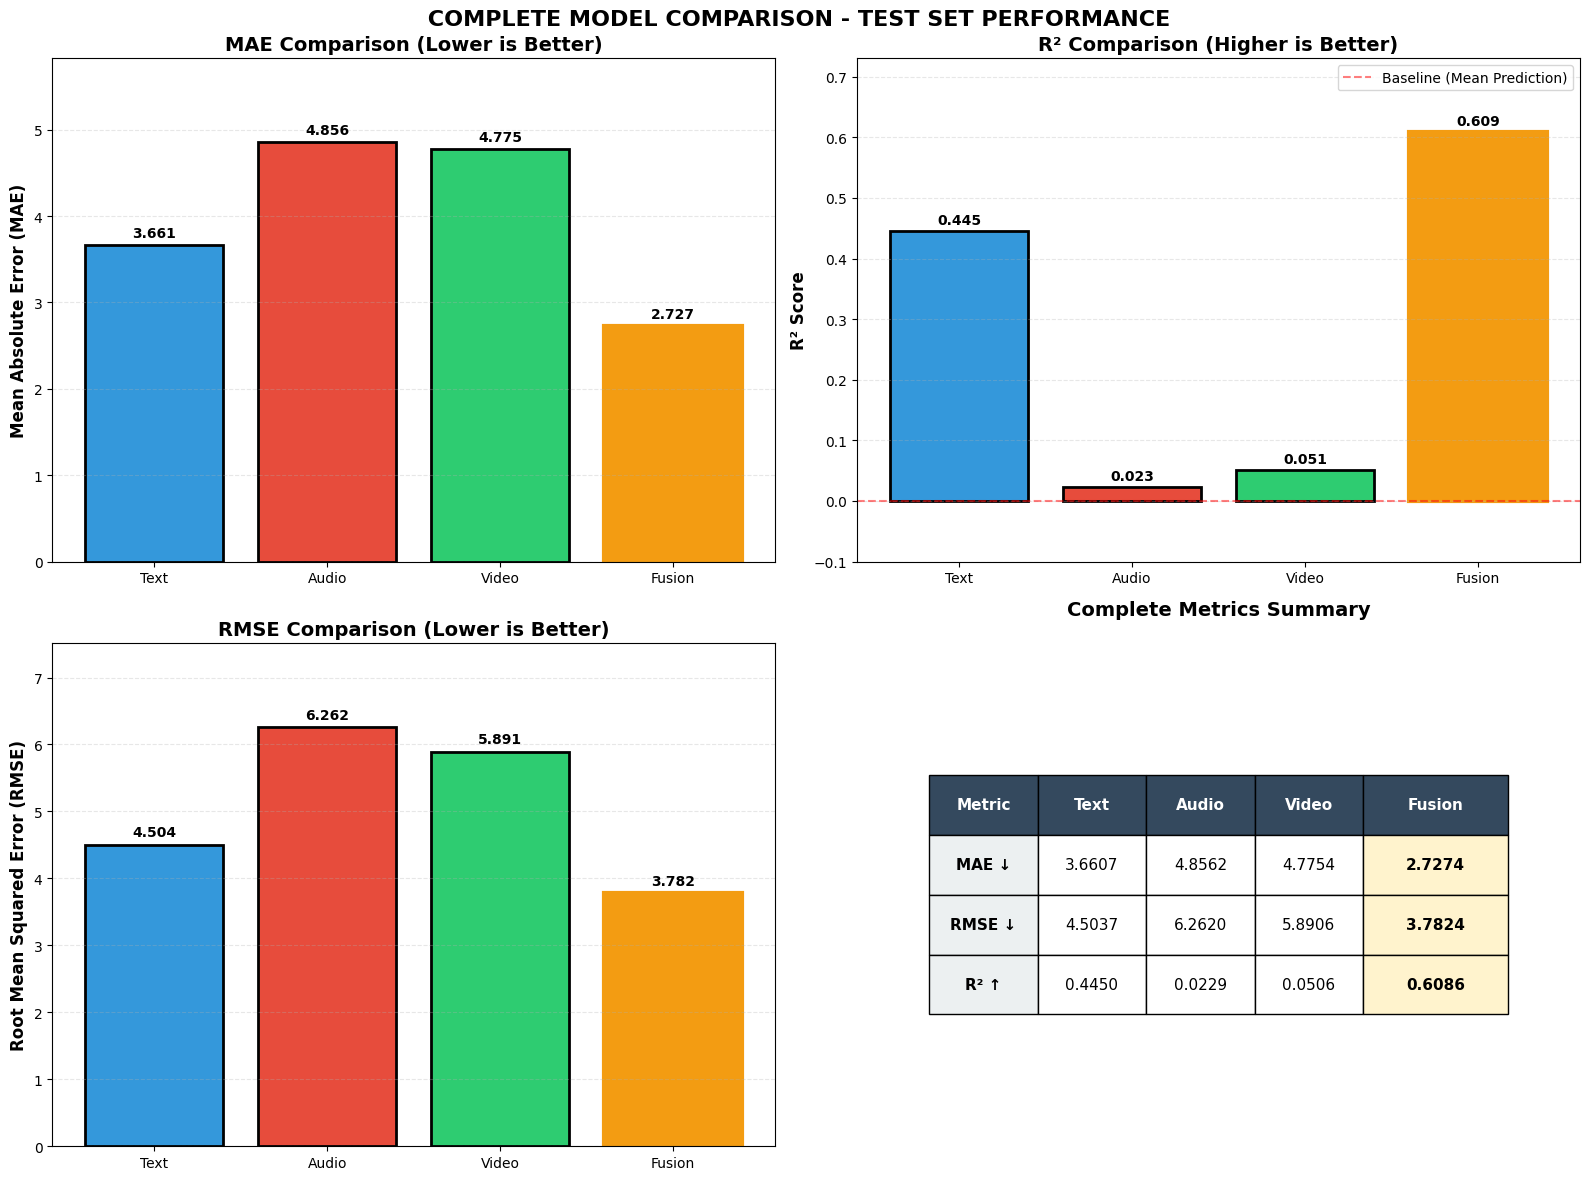


📊 Visual comparison complete!


In [ ]:
# ============================================
# VISUAL COMPARISON: ALL MODELS
# ============================================

import matplotlib.pyplot as plt
import numpy as np

# Create comprehensive comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Prepare data for comparison
models = ['Text', 'Audio', 'Video', 'Fusion']
mae_values = [
    text_test_metrics['MAE'],
    audio_test_metrics['MAE'],
    video_test_metrics['MAE'],
    fusion_test_metrics['MAE']
]
r2_values = [
    text_test_metrics['R2'],
    audio_test_metrics['R2'],
    video_test_metrics['R2'],
    fusion_test_metrics['R2']
]
rmse_values = [
    text_test_metrics['RMSE'],
    audio_test_metrics['RMSE'],
    video_test_metrics['RMSE'],
    fusion_test_metrics['RMSE']
]

colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']  # Blue, Red, Green, Orange
fusion_color = '#f39c12'

# 1. MAE Comparison
ax1 = axes[0, 0]
bars1 = ax1.bar(models, mae_values, color=colors, edgecolor='black', linewidth=2)
bars1[-1].set_color(fusion_color)
bars1[-1].set_linewidth(3)
ax1.set_ylabel('Mean Absolute Error (MAE)', fontsize=12, fontweight='bold')
ax1.set_title('MAE Comparison (Lower is Better)', fontsize=14, fontweight='bold')
ax1.set_ylim([0, max(mae_values) * 1.2])
ax1.grid(axis='y', alpha=0.3, linestyle='--')
for i, v in enumerate(mae_values):
    ax1.text(i, v + max(mae_values)*0.02, f'{v:.3f}', ha='center', fontweight='bold')

# 2. R² Comparison
ax2 = axes[0, 1]
bars2 = ax2.bar(models, r2_values, color=colors, edgecolor='black', linewidth=2)
bars2[-1].set_color(fusion_color)
bars2[-1].set_linewidth(3)
ax2.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax2.set_title('R² Comparison (Higher is Better)', fontsize=14, fontweight='bold')
ax2.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Baseline (Mean Prediction)')
ax2.set_ylim([min(min(r2_values) - 0.1, -0.1), max(r2_values) * 1.2])
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.legend()
for i, v in enumerate(r2_values):
    ax2.text(i, v + max(r2_values)*0.02, f'{v:.3f}', ha='center', fontweight='bold')

# 3. RMSE Comparison
ax3 = axes[1, 0]
bars3 = ax3.bar(models, rmse_values, color=colors, edgecolor='black', linewidth=2)
bars3[-1].set_color(fusion_color)
bars3[-1].set_linewidth(3)
ax3.set_ylabel('Root Mean Squared Error (RMSE)', fontsize=12, fontweight='bold')
ax3.set_title('RMSE Comparison (Lower is Better)', fontsize=14, fontweight='bold')
ax3.set_ylim([0, max(rmse_values) * 1.2])
ax3.grid(axis='y', alpha=0.3, linestyle='--')
for i, v in enumerate(rmse_values):
    ax3.text(i, v + max(rmse_values)*0.02, f'{v:.3f}', ha='center', fontweight='bold')

# 4. Combined Metrics Radar Chart
ax4 = axes[1, 1]
ax4.axis('off')

# Create summary table
summary_data = [
    ['Metric', 'Text', 'Audio', 'Video', 'Fusion'],
    ['MAE ↓', f'{mae_values[0]:.4f}', f'{mae_values[1]:.4f}', f'{mae_values[2]:.4f}', f'{mae_values[3]:.4f}'],
    ['RMSE ↓', f'{rmse_values[0]:.4f}', f'{rmse_values[1]:.4f}', f'{rmse_values[2]:.4f}', f'{rmse_values[3]:.4f}'],
    ['R² ↑', f'{r2_values[0]:.4f}', f'{r2_values[1]:.4f}', f'{r2_values[2]:.4f}', f'{r2_values[3]:.4f}'],
]

# Create table
table = ax4.table(cellText=summary_data, cellLoc='center', loc='center',
                  colWidths=[0.15, 0.15, 0.15, 0.15, 0.2])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 3)

# Style header row
for i in range(5):
    cell = table[(0, i)]
    cell.set_facecolor('#34495e')
    cell.set_text_props(weight='bold', color='white')

# Style data rows
for i in range(1, 4):
    for j in range(5):
        cell = table[(i, j)]
        if j == 0:  # Metric name column
            cell.set_facecolor('#ecf0f1')
            cell.set_text_props(weight='bold')
        elif j == 4:  # Fusion column
            cell.set_facecolor('#fff3cd')
            cell.set_text_props(weight='bold')
        else:
            cell.set_facecolor('#ffffff')

ax4.set_title('Complete Metrics Summary', fontsize=14, fontweight='bold', pad=20)

plt.suptitle(' COMPLETE MODEL COMPARISON - TEST SET PERFORMANCE',
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("📊 Visual comparison complete!")
print("="*80)